In [2]:
import numpy as np
import pandas as pd

df = pd.read_csv('../data/raw/icm_general.csv')
df['fecha'] = pd.to_datetime(df['fecha'])
df.head()

,fecha,valor
0,2001-04-01,106.497
1,2001-05-01,110.248
2,2001-06-01,115.677
3,2001-07-01,104.417
4,2001-08-01,104.088


## Interpolacion sobre outlier del COVID

In [2]:
mask_covid = (df['fecha'] >= '2020-03-01') & (df['fecha'] <= '2020-04-01')

df['valor_icm_clean'] = df['valor'].copy()
df.loc[mask_covid, 'valor_icm_clean'] = np.nan

df['valor_icm_clean'] = df['valor_icm_clean'].interpolate(method='linear')

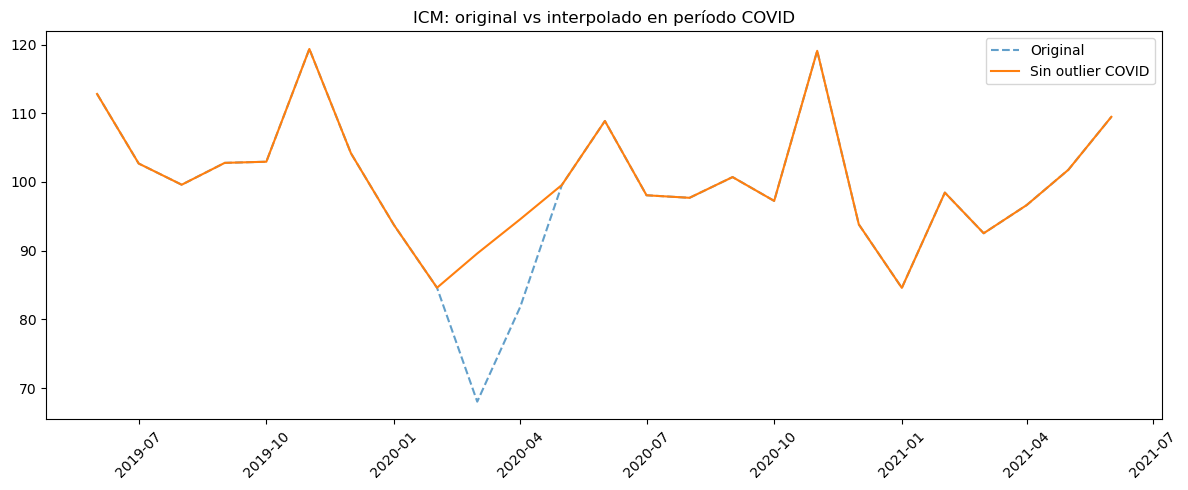

In [3]:
import matplotlib.pyplot as plt

mask_viz = (df['fecha'] >= '2019-06-01') & (df['fecha'] <= '2021-06-01')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.loc[mask_viz, 'fecha'], df.loc[mask_viz, 'valor'], 
        label='Original', linestyle='--', alpha=0.7)
ax.plot(df.loc[mask_viz, 'fecha'], df.loc[mask_viz, 'valor_icm_clean'], 
        label='Sin outlier COVID')
ax.legend()
ax.set_title('ICM: original vs interpolado en período COVID')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/05_covid_interpolado.png', dpi=150)
plt.show()

## Variables temporales

In [4]:
# Variables de calendario
df['mes'] = df['fecha'].dt.month
df['anyo'] = df['fecha'].dt.year

# Variables binarias de períodos clave
df['es_navidad'] = df['mes'].isin([11,12]).astype(int)
df['es_rebajas'] = df['mes'].isin([1,7]).astype(int)

# Lag features 
df['lag_1'] = df['valor_icm_clean'].shift(1)
df['lag_12'] = df['valor_icm_clean'].shift(12)

# Rolling mean
df['rolling_mean_3'] = df['valor_icm_clean'].rolling(window=3).mean()

In [ ]:
df.head()

,fecha,valor,valor_icm_clean,mes,anyo,es_navidad,es_rebajas,lag_1,lag_12,rolling_mean_3
0,2001-04-01,106.497,106.497,4,2001,0,0,NaN,NaN,NaN
1,2001-05-01,110.248,110.248,5,2001,0,0,106.497,NaN,NaN
2,2001-06-01,115.677,115.677,6,2001,0,0,110.248,NaN,110.807333
3,2001-07-01,104.417,104.417,7,2001,0,1,115.677,NaN,110.114000
4,2001-08-01,104.088,104.088,8,2001,0,0,104.417,NaN,108.060667


In [6]:
# Eliminacion de valores nulos
df = df.dropna().reset_index(drop=True)
df.shape

(288, 10)

## Merge con IPC

In [7]:
df_ipc = pd.read_csv('../data/raw/ipc_general.csv')
df_ipc['fecha'] = pd.to_datetime(df_ipc['fecha'])
df_ipc['fecha'] = df_ipc['fecha'].dt.to_period('M').dt.to_timestamp()
df_ipc = df_ipc.rename(columns={'valor':'valor_ipc'})

df = pd.merge(df, df_ipc, how='left', on='fecha')
print(df.isnull().sum())

fecha              0
valor              0
valor_icm_clean    0
mes                0
anyo               0
es_navidad         0
es_rebajas         0
lag_1              0
lag_12             0
rolling_mean_3     0
valor_ipc          4
dtype: int64


In [8]:
# Forward fill para nulos en valor_ipc
df['valor_ipc'] = df['valor_ipc'].ffill()
print(df.isnull().sum())

fecha              0
valor              0
valor_icm_clean    0
mes                0
anyo               0
es_navidad         0
es_rebajas         0
lag_1              0
lag_12             0
rolling_mean_3     0
valor_ipc          0
dtype: int64


In [9]:
df.to_parquet('../data/processed/icm_features.parquet', index=False)

Con los datos ya procesados pasamos a la siguiente etapa:
- Creación de baseline con Naive Seasonal.
- Modelado con SARIMA e identificación de parámetros p, d, q con ACF y PACF.
- Prueba de modelos Prophet y LigthGBM para comparar con enfoque estadistico clásico en términos de MAPE.
- Evaluación con walk-forward validation. 